# Ru-Tokenizer

In [1]:
import tqdm
import polars as pl

from nltk import word_tokenize
from datasets import load_dataset

In [8]:
import seaborn as sns
import numpy as np
import random


class BiernouliFreqCV:
    def __init__(self, q=0.1, n=100):
        self.q = q
        self.n = n

    def _single_sample(self):
        res = random.uniform(0,1) <= self.q
        return int(res)
    
    def sample(self, k=1):
        out = []
        for _ in range(k):
            res = 0
            for _ in range(self.n):
                res += self._single_sample()
            out.append(res / self.n)
        return out

In [23]:
np.array(BiernouliFreqCV(q=0.1, n=100).sample(k=100000)).std()

np.float64(0.02995509973276671)

In [24]:
0.1*0.9*0.01

0.0009000000000000001

np.float64(0.009400200795727717)

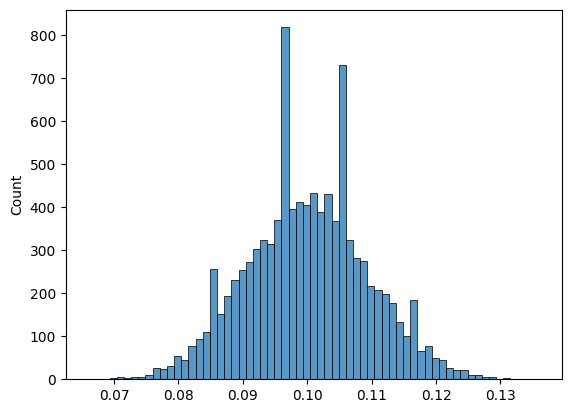

In [30]:
a = np.array(BiernouliFreqCV(q=0.1, n=1000).sample(k=10000))

sns.histplot(a)
a.std()

p(1-p)/n

class CV:
    n 

We'll use [`RussianNLP/coat`](https://huggingface.co/datasets/RussianNLP/coat) as a baseline dataset for making our tokenizer

In [16]:
DSET_NAME = "RussianNLP/coat"

ds = load_dataset(DSET_NAME, "binary")

train_df = pl.from_arrow(ds.data["train"].to_batches())

In [17]:
text_raw = train_df.select(pl.col("text")).to_struct()

## Build a tokenizer module

`vocab.py`

In [25]:
import numba as nb


@nb.jit()
def preprocess_map__collect_symmap(text_chunks) -> nb.typed.Dict:
    acc = nb.typed.Dict.empty(
        key_type=nb.types.unicode_type,
        value_type=nb.types.int64,
    )
    for chunk in text_chunks:
        for sym in chunk:
            cnt = acc.get(sym, 0)
            acc[sym] = cnt + 1
    return acc


@nb.jit()
def preprocess_reduce__collect_symmap(accumulators) -> nb.typed.Dict:
    acc = nb.typed.Dict.empty(
        key_type=nb.types.unicode_type,
        value_type=nb.types.int64,
    )
    for _acc in accumulators:
        for _k, _v in _acc.items():
            cnt = acc.get(_k, 0)
            acc[_k] = cnt + _v
    return acc

In [29]:
chunks = [
    [
        "".join(["Р"] * 6),
        "".join(["к"] * 12),
    ],
    [
        "".join(["*"] * 6),
        "".join(["z"] * 12),
    ],
    [
        "".join(["z"] * 6),
        "".join(["*"] * 12),
        "".join(["ю"] * 12),
    ],
]
print(chunks)

res = nb.typed.List()
for chunk in chunks:
    res.append(preprocess_map__collect_symmap(chunk))
acc = preprocess_reduce__collect_symmap(res)

[['РРРРРР', 'кккккккккккк'], ['******', 'zzzzzzzzzzzz'], ['zzzzzz', '************', 'юююююююююююю']]


In [30]:
acc

DictType[unicode_type,int64]<iv=None>({Р: 6, к: 12, *: 18, z: 18, ю: 12})

In [20]:
acc = nb.typed.Dict.empty(
        key_type=nb.types.unicode_type,
        value_type=nb.types.int64,
    )

In [21]:
acc.get("12", 1)

1

`builder.py`

`tokenizer.py`

### Sandbox space

Test tokenizer